# Project 06: GEARS training and comparison

This local experiment trained the installed GEARS architecture on **7,584 sampled training cells**, up to **32 per original condition label**, using all 237 training labels. The full split contains 79,170 training cells; this is a smaller local run, not a full-data paper reproduction.

Both graph construction and prediction inputs use training information. The ontology graph comes from the local GEARS reference. The co-expression graph uses sampled training singles and controls. There are **88 training, 20 validation, and 20 test gene pairs**, with all single-gene identities and controls in training. Equivalent perturbation labels remain in the same split.

The best checkpoint was epoch **12** of **17** completed epochs, selected on validation top-20 DE MSE. Training used the standard GEARS loss, Adam and the original 0.5-per-epoch learning-rate schedule. Test scores were calculated after fixing that checkpoint.

Evaluation uses the same saved DE genes and pair averaging as the additive baseline. Inference averages 32 repeated mean-control profiles per condition, providing deterministic predictions on the original processed expression scale. The model is evaluated on mean expression, rather than its ability to predict individual-cell noise.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

run_dir = Path("results/gears_local")
summary = pd.read_csv(run_dir / "model_comparison.csv")
display(summary)


,split,model,pairs,mse_de20,mse_all_genes
0,test,additive,20,0.060234,0.001989
1,test,control,20,0.538783,0.008964
2,test,gears_local,20,0.139134,0.008670
3,val,additive,20,0.034835,0.001378
4,val,control,20,0.521596,0.006626
5,val,gears_local,20,0.131966,0.006929


## Test comparison

Lower error is better. These three models use the same 20 test pairs.


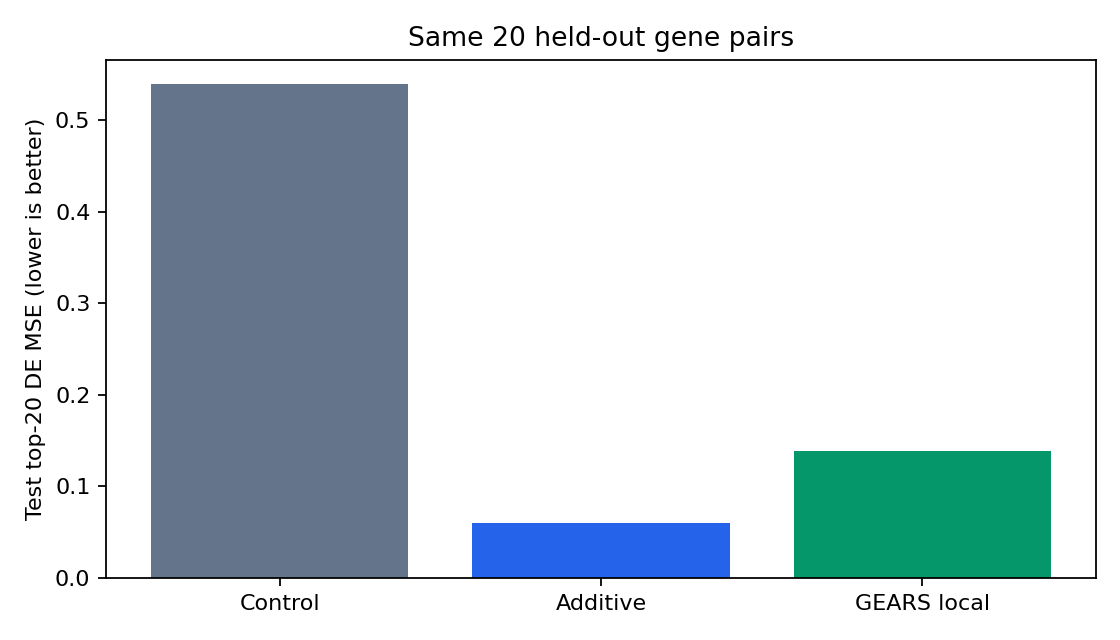

In [2]:
display(Image(filename=str(run_dir / "model_comparison.png")))


## Validation history

The selected checkpoint is shown below. Test performance was not used to select epochs.


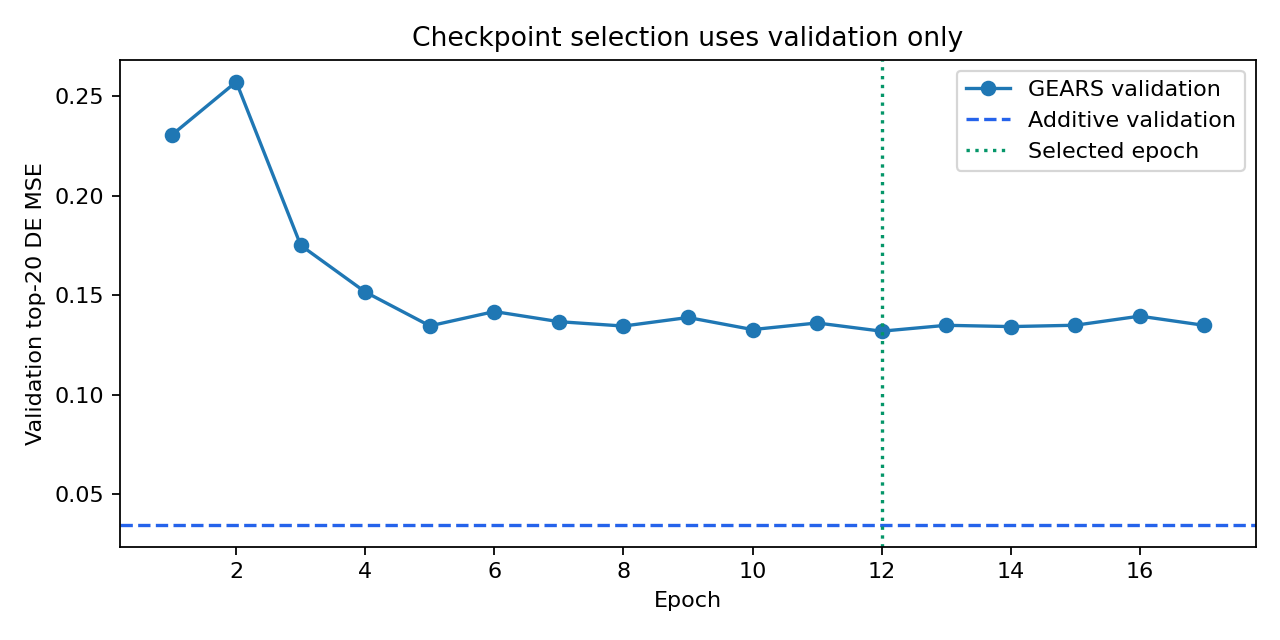

In [3]:
display(Image(filename=str(run_dir / "training_history.png")))


## Descriptive test examples

Two lowest-error and two highest-error GEARS pairs. These examples were selected after scoring for explanation, not tuning.


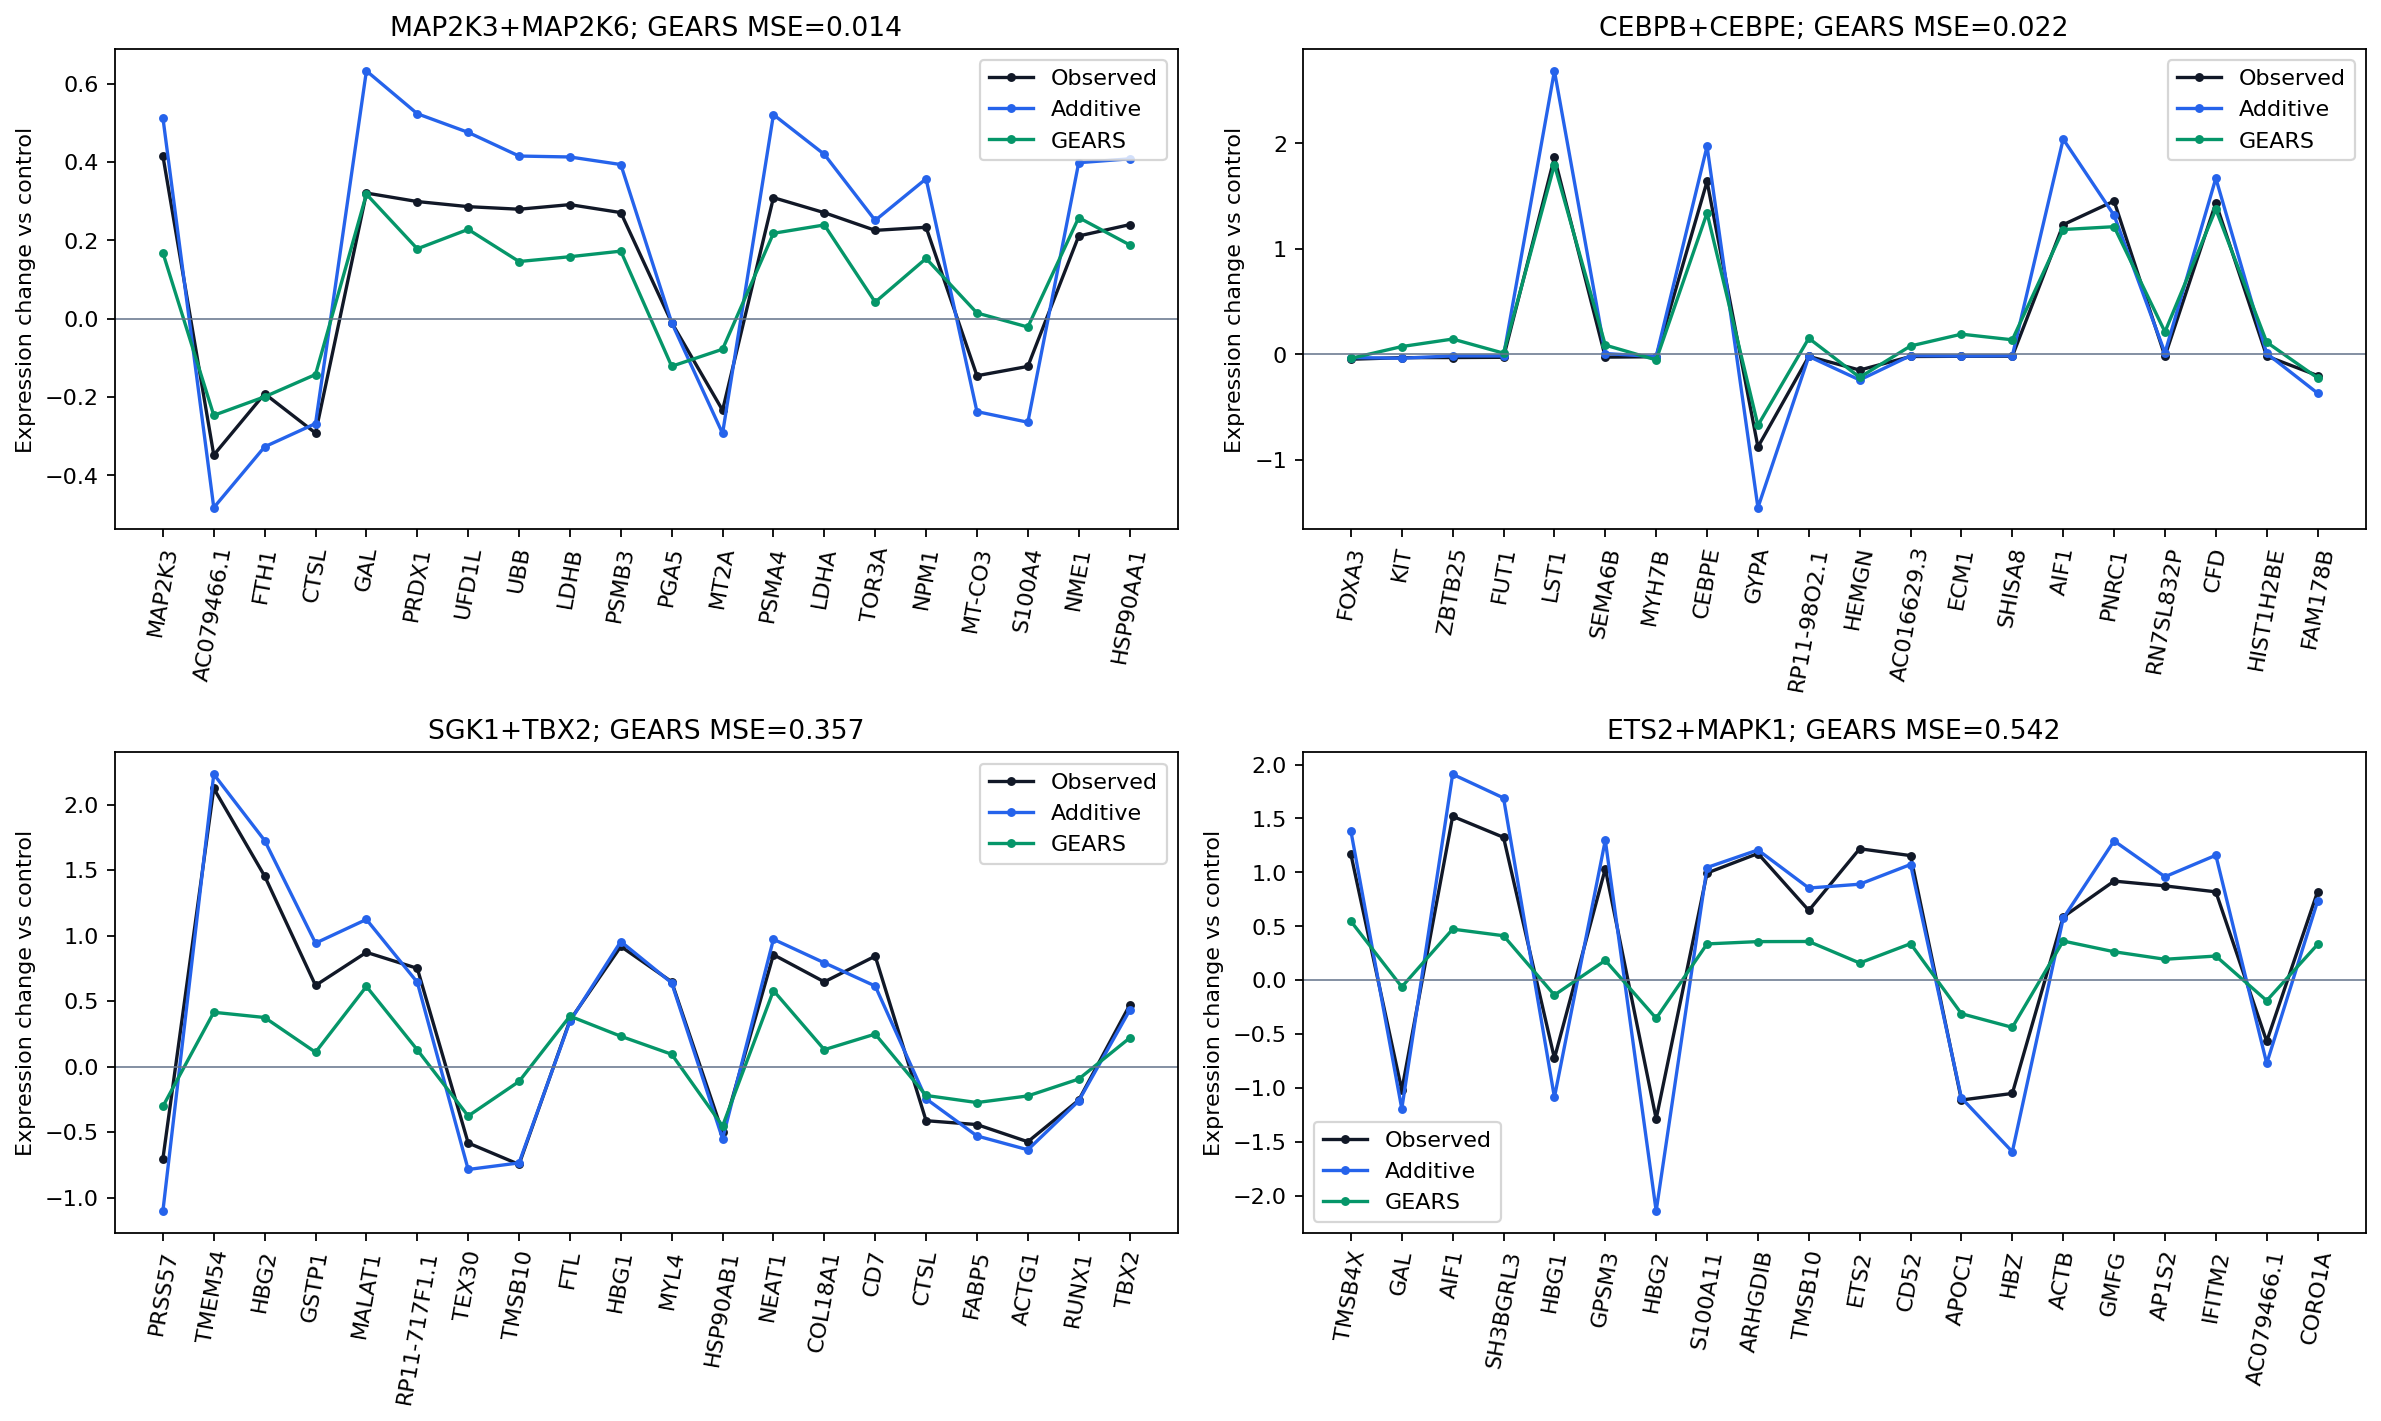

In [4]:
display(Image(filename=str(run_dir / "test_examples.png")))


## Historical pilot and current workflow

This notebook preserves the original capped pilot's executed outputs. Its training implementation, graph policy, and schedule preceded the audited full-data experiment. The current training script has different defaults, so its former training command does not reproduce this pilot. Selecting the current `official` runtime alone does not restore the complete old protocol.

See `README.md` for the current full-data reproduction command and `AUDIT.md` for the changes. The pilot's metrics and training history remain in `results/gears_local/`; local `model.pt` and `config.pkl` retain its selected checkpoint and graph configuration.

Verify the preserved local pilot checkpoint without training:

```bash
python3 train_project06.py --output-dir results/gears_local --verify-checkpoint
```

Checkpoint binaries are excluded from Git. A fresh clone can inspect the stored results but must train to create new weights.

Limitations: one random split and one seed; capped training cells; graph ties may depend on library versions; same-dataset prediction of new combinations of seen genes. This does not establish generalization to new genes, new cell types, or biological replicates. The biological experiment used CRISPR activation; no gene knockouts are being claimed.
